# UNIVERSIDAD INTERNACIONAL DE VALENCIA
## MIAR - ALGORITMOS DE OPTIMIZACIÓN

**Nombre:** Graciela Elizabeth Medina Topanta

**GoogleColab:** https://drive.google.com/drive/folders/1RTAVTssCcB-UHXLEN4JlCDt6_2Hpm6yX?usp=drive_link

**Github:** https://github.com/gemedinat/MIAR_ALGORITMOS_DE_OPTIMIZACION.git

In [1]:
#Modulo de llamadas http para descargar ficheros
!pip install requests

#Libreria del problema TSP: http://elib.zib.de/pub/mp-testdata/tsp/tsplib/tsplib.html
!pip install tsplib95

In [2]:
import tsplib95
import random
from math import e
import urllib.request

In [3]:
#DATOS DEL PROBLEMA
file = "swiss42.tsp"
# urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())
Aristas = list(problem.get_edges())

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion(lista de nodos)
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

problem.get_weight(3, 0)


23

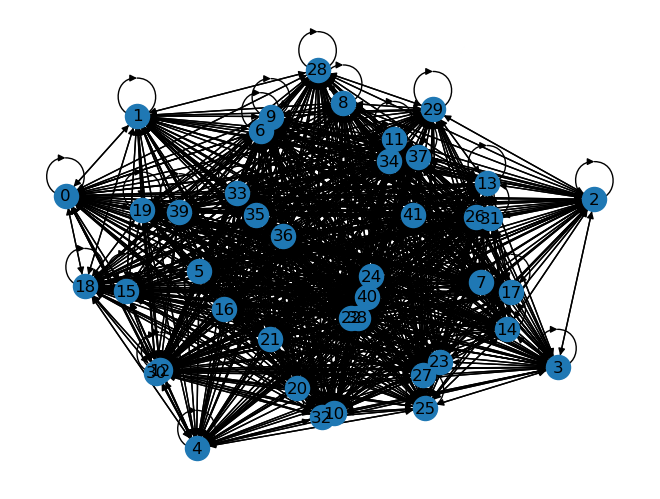

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
nx.draw(problem.get_graph(), with_labels=True, arrows=True)
plt.show()

In [8]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo TSP con solución específica")
    plt.show()

In [5]:
# Genera una solución aleatoria con comienzo en en el nodo 0
def crear_solucion(nodos):
    # Nodo inicial = 0
    solucion = [nodos[0]]
    # Para el resto de nodos, los recorremos e incluimos aleatoriamente en la solución cada uno de ellos
    for n in nodos[1:]:
        # Debemos quitar el nodo 0 y los ya incluidos en cada iteración
        solucion = solucion + [random.choice(list(set(nodos) - set({nodos[0]}) - set(solucion)))]
    return solucion

# Devuelve la distancia entre dos nodos aprovechando la función get_weight() de tsplib95
def distancia(a,b, problema):
    return problema.get_weight(a,b)

# Devuelve la distancia total de una trayectoria/solución
def distancia_total(solucion, problema):
    distancia_total = 0
    # Para cada nodo de la solución calculamos su distancia a siguiente nodo
    for i in range(len(solucion)-1):
        distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problema)
    # Devolvemos la distancia total más la distancia del último nodo al primero para cerrar viaje
    return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problema)

#solucion = crear_solucion(nodos)
#print(solucion)
#print(distancia_total(solucion, problema))

## Algoritmo de colonia de hormigas

La función Add_Nodo selecciona al azar un nodo con probabilidad uniforme.
Para ser mas eficiente debería seleccionar el próximo nodo siguiendo la probabilidad correspondiente a la ecuación:

$p^k_{ij}(t) = \frac{[\tau_{ij}(t)]^\alpha[\nu_{ij}]^\beta}{\sum_{l\in J^k_i} [\tau_{il}(t)]^\alpha[\nu_{il}]^\beta}$, si $j \in J^k_i$

$p^k_{ij}(t) = 0$, si $j \notin J^k_i$

In [6]:
def Add_Nodo(problem, H, T):
  #Mejora:Establecer una funcion de probabilidad para
  # añadir un nuevo nodo dependiendo de los nodos mas cercanos y de las feromonas depositadas
  Nodos = list(problem.get_nodes())
  return random.choice(list(set(range(1,len(Nodos))) - set(H)))

def Incrementa_Feromona(problem, T, H):
  #Incrementa segun la calidad de la solución. Añadir una cantidad inversamente proporcional a la distancia total
  for i in range(len(H)-1):
    T[H[i]][H[i+1]] += 1000/distancia_total(H, problem)
  return T

def Evaporar_Feromonas(T):
  #Evapora 0.3 el valor de la feromona, sin que baje de 1
  #Mejora:Podemos elegir diferentes funciones de evaporación dependiendo de la cantidad actual y de la suma total de feromonas depositadas,...
  T = [[max(T[i][j] - 0.3 , 1) for i in range(len(Nodos)) ] for j in range(len(Nodos))]
  return T

La mejor solución encontrada es: [0, 11, 32, 15, 20, 17, 14, 27, 39, 24, 30, 13, 21, 18, 5, 9, 41, 25, 40, 23, 1, 3, 29, 10, 12, 38, 22, 28, 8, 34, 19, 31, 36, 35, 7, 16, 6, 26, 37, 33, 2, 4] con 5000 hormigas
Distancia: 3741


C:\Users\asus\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


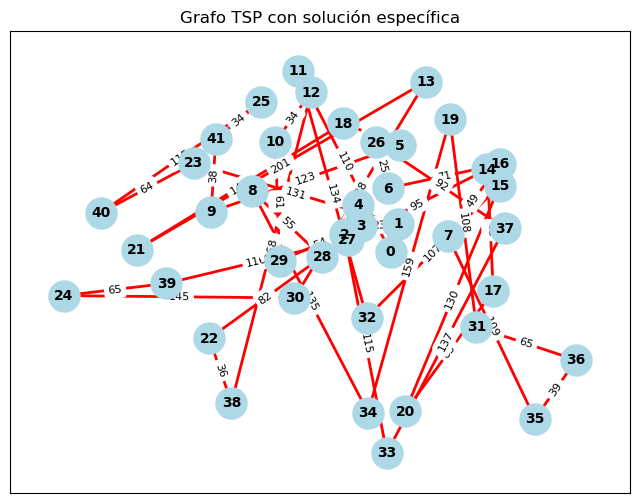

In [11]:
def hormigas(problem, N) :
  #problem = datos del problema
  #N = Número de agentes(hormigas)

  #Nodos
  Nodos = list(problem.get_nodes())
  #Aristas
  Aristas = list(problem.get_edges())

  #Inicializa las aristas con una cantidad inicial de feromonas:1
  #Mejora: inicializar con valores diferentes dependiendo diferentes criterios
  T = [[ 1 for _ in range(len(Nodos)) ] for _ in range(len(Nodos))]

  #Se generan los agentes(hormigas) que serán estructuras de caminos desde 0
  Hormiga = [[0] for _ in range(N)]

  #Recorre cada agente construyendo la solución
  for h in range(N) :
    #Para cada agente se construye un camino
    for i in range(len(Nodos)-1) :

      #Elige el siguiente nodo
      Nuevo_Nodo = Add_Nodo(problem, Hormiga[h] ,T )
      Hormiga[h].append(Nuevo_Nodo)

    #Incrementa feromonas en esa arista
    T = Incrementa_Feromona(problem, T, Hormiga[h] )
    #print("Feromonas(1)", T)

    #Evapora Feromonas
    T = Evaporar_Feromonas(T)
    #print("Feromonas(2)", T)

    #Seleccionamos el mejor agente
  mejor_solucion = []
  mejor_distancia = 10e100
  for h in range(N) :
    distancia_actual = distancia_total(Hormiga[h], problem)
    if distancia_actual < mejor_distancia:
      mejor_solucion = Hormiga[h]
      mejor_distancia =distancia_actual

  return mejor_solucion, mejor_distancia

n_hormigas = 5000
mejor_solucion, mejor_distancia  = hormigas(problem, n_hormigas)

print(f"La mejor solución encontrada es: {mejor_solucion} con {n_hormigas} hormigas")
print(f"Distancia: {mejor_distancia}")

plot_tsp_solution(problem.edge_weights, mejor_solucion)

## Optimización Colonia Hormigas (ACO) mejorado - TSP
- Uso de solución constructiva basada en feromonas y evaporación
- Aquí cada agente (hormiga) construye un camino y deja feromonas de modo que otras hormigas "siguen" el rastro
- Las feromonas importan a la hora de elegir siguiente nodo


**Errores en código:**

- El algoritmo se encuentra llamando a la función de forma desordenada y cuenta con los argumentos desordenados, dentro del bucle se invoca Add_Nodo(hormigas, nodos, T, problema), que es la versión vieja de selección aleatoria uniforme, no la anadir_nodo probabilística se define con α y β.
- El centinela debería ser float('inf'), y no hace falta un segundo bucle final ni guardar las 5000 hormigas en memoria: se puede rastrear la mejor sobre la marcha, construyendo cada tour en una variable local.

C:\Users\asus\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


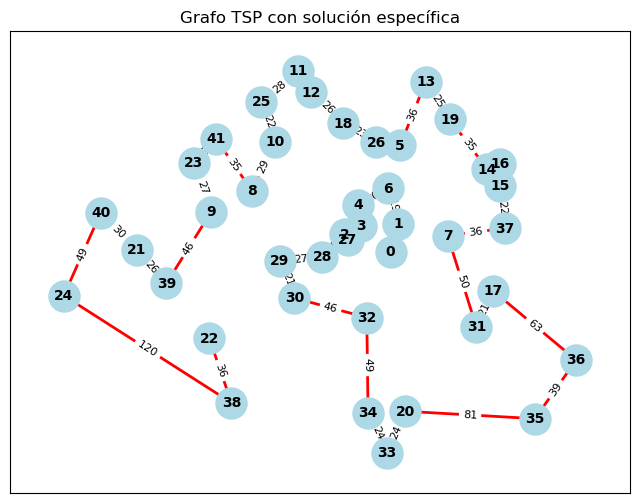

In [18]:
# Matriz completa y simétrica para el plot 
import numpy as np

nodos_plot = list(problem.get_nodes())
matriz_distancias = np.array([[problem.get_weight(i, j) for j in nodos_plot]
                              for i in nodos_plot])
plot_tsp_solution(matriz_distancias, mejor_solucion)

In [20]:
def anadir_nodo(hormiga, nodos, T, problema, alpha=1, beta=2):
    # Robusto: la resta de conjuntos ya excluye el nodo inicial (está en hormiga)
    candidatos = list(set(range(len(nodos))) - set(hormiga))
    i = hormiga[-1]  # nodo actual

    probabilidades = []
    for j in candidatos:
        tau = T[i][j]                           # feromona
        eta = 1 / (distancia(i, j, problema) + 1e-6)  # visibilidad
        probabilidades.append((tau ** alpha) * (eta ** beta))

    suma = sum(probabilidades)
    probabilidades = [p / suma for p in probabilidades]
    return random.choices(candidatos, weights=probabilidades, k=1)[0]


def incrementar_feromona(problema, T, hormiga, Q=1000):
    # La distancia se calcula UNA vez, no en cada iteración del bucle
    aporte = Q / distancia_total(hormiga, problema)
    for i in range(len(hormiga) - 1):
        T[hormiga[i]][hormiga[i+1]] += aporte
        T[hormiga[i+1]][hormiga[i]] += aporte   # simetría: TSP no dirigido
    # Arista de cierre del ciclo (faltaba en el original)
    T[hormiga[-1]][hormiga[0]] += aporte
    T[hormiga[0]][hormiga[-1]] += aporte
    return T


def evaporar_feromonas(T, nodos, rho=0.1, tau_min=0.1):
    # CORREGIDO: bucle j interno, i externo -> el resultado [i][j] lee T[i][j],
    # ya NO se transpone la matriz. Evaporación multiplicativa estándar.
    n = len(nodos)
    return [[max(T[i][j] * (1 - rho), tau_min) for j in range(n)] for i in range(n)]

La mejor solución encontrada es: [0, 1, 6, 4, 3, 27, 2, 28, 30, 29, 32, 34, 33, 20, 35, 36, 17, 31, 7, 37, 15, 16, 14, 19, 13, 5, 26, 18, 12, 11, 25, 10, 41, 23, 9, 8, 21, 40, 24, 39, 22, 38] con 500 hormigas
Distancia: 1394


C:\Users\asus\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


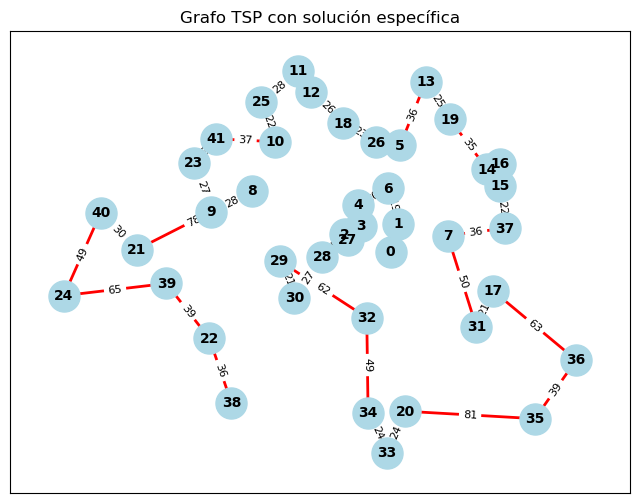

In [21]:
def aco(problema, n_hormigas, alpha=1, beta=2, rho=0.1):
    nodos = list(problema.get_nodes())
    n = len(nodos)

    # Matriz de feromonas inicial: 1.0 en todas las aristas
    # Mejora: inicializar con 1/(n * L_greedy) como en Ant System clásico
    T = [[1.0 for _ in range(n)] for _ in range(n)]

    mejor_solucion, mejor_distancia = [], float('inf')   # antes 10e100

    for _ in range(n_hormigas):
        # Cada hormiga construye su camino desde el nodo 0
        hormiga = [0]
        for _ in range(n - 1):
            # CORREGIDO: se invoca la regla probabilística anadir_nodo
            # (antes se llamaba a Add_Nodo, la selección uniforme,
            #  y con los argumentos en orden incorrecto)
            hormiga.append(anadir_nodo(hormiga, nodos, T, problema, alpha, beta))

        # Depósito y evaporación tras completar el tour
        T = incrementar_feromona(problema, T, hormiga)
        T = evaporar_feromonas(T, nodos, rho)

        # Seguimiento de la mejor sobre la marcha (evita el 2º bucle
        # y guardar las n_hormigas listas en memoria)
        d = distancia_total(hormiga, problema)
        if d < mejor_distancia:
            mejor_solucion, mejor_distancia = hormiga, d

    return mejor_solucion, mejor_distancia


n_hormigas = 500   # con selección probabilística basta; 5000 era fuerza bruta
mejor_solucion, mejor_distancia = aco(problem, n_hormigas)

print(f"La mejor solución encontrada es: {mejor_solucion} con {n_hormigas} hormigas")
print(f"Distancia: {mejor_distancia}")

# Matriz completa y simétrica para el plot (edge_weights no es fiable para MDS)
import numpy as np
matriz_distancias = np.array([[problem.get_weight(i, j) for j in nodos_plot]
                              for i in nodos_plot])  # nodos_plot = list(problem.get_nodes())
plot_tsp_solution(matriz_distancias, mejor_solucion)

## Algoritmos genéticos y evolutivos - TSP
- Se comienza con una población inicial y se van aplicando criterios incluyendo selección, cruzamiento, mutación y factibilidad entre otros para resolver el problema
- Se realizan una serie de iteraciones que permiten ir "mejorando la especie" hasta converger a soluciones mejores
- Hay un componente probabilista importante y que se puede modificar con hiperparámetros

In [22]:
import copy

# Genera una población inicial de soluciones de tamaño tamano_poblacion.
# Puede ser válida la solución aleatoria de la AG3: crear_solucion(nodos)
def generar_poblacion(nodos,tamano_poblacion):
    return [crear_solucion(nodos) for _ in range(tamano_poblacion)]

In [23]:
# Evalúa la población y devuelve el mejor individuo
def evaluar_poblacion(poblacion, problema):
    mejor_solucion = []
    mejor_distancia = float("inf")

    for p in poblacion:
        distancia_referencia = distancia_total(p, problema)
        if (distancia_referencia < mejor_distancia):
            mejor_solucion = p
            mejor_distancia = distancia_referencia

    return mejor_solucion, mejor_distancia

In [24]:
# Función de cruce. Recibe una población (lista de soluciones) y devuelve la población ampliada con los hijos.
# Todos los individuos de la población son selecionados para el cruce (si la población es par)
# Podría aplicarse un proceso previo de selección para elegir los individuos que se desea cruzar.
def cruzar(poblacion, mutacion, problema):
    poblacion_copia = copy.deepcopy(poblacion)
    poblacion_final = copy.deepcopy(poblacion)

    while(len(poblacion_copia) > 1):
        padre1, padre2 = random.sample(poblacion_copia, 2)
        poblacion_copia.remove(padre1)
        poblacion_copia.remove(padre2)
        poblacion_final.extend(descendencia([padre1, padre2], problema, mutacion))

    return poblacion_final

In [25]:
# Función para generar hijos a partir de 2 padres:
# Se elige el metodo de 1-punto de corte pero es posible usar otros n-puntos, uniforme, dependiendo del problema
def descendencia(padres, problema, mutacion):
    punto_corte = random.sample(range(1, len(padres[0])), 1)[0]

    hijo1 = padres[0][:punto_corte] + padres[1][punto_corte:]
    hijo2 = padres[1][:punto_corte] + padres[0][punto_corte:]

    hijo1 = factibilizar(hijo1, problema)
    hijo2 = factibilizar(hijo2, problema)

    mutacion1 = mutar(hijo1, mutacion)
    mutacion2 = mutar(hijo2, mutacion)

    mutacion1 = factibilizar(mutacion1, problema)
    mutacion2 = factibilizar(mutacion2, problema)

    return [hijo1, hijo2, mutacion1, mutacion1]

In [27]:
# Para el operador de cruce 1-punto los hijos generados no son soluciones (algunos nodos se repiten y otros no están)
def factibilizar(solucion, problema):
    solucion = solucion[:]

    nodos = list(problema.get_nodes())
    nodos_desaparecidos = list(set(nodos) - set(solucion))

    usados = {}

    for i in range(len(solucion)):
        if solucion[i] in usados:
            solucion[i] = nodos_desaparecidos.pop(0)
        else:
            usados[solucion[i]] = True

    return solucion

In [28]:
# Función de mutación. Se eligen dos nodos y se intercambia. Se podrían añadir otros operaradores
# Se hace mutaciones mutacion% de las veces
def mutar(solucion, mutacion):
    if random.random() < mutacion:
        i, j = random.sample(range(len(solucion)), 2)

        solucion = solucion[:]
        solucion[i], solucion[j] = solucion[j], solucion[i]

        return solucion

    return solucion[:]

In [29]:
# Función de selección de la población. Recibe como parámetro una población y
# devuelve una población a la que se ha eliminado individuos poco aptos (fitness alto) y para mantener una población estable de tamano_poblacion individuos
# Se tiene en cuenta el porcentaje elitismo pasado como parámetro
# Para los individuos que no son de la élite podríamos usar una selección de ruleta (proporcional a su fitness)
def seleccionar(problema, poblacion, tamano_poblacion, elitismo):
    # Se ordena la población según el fitness (tamaño del recorrido) en una lista de elementos [distancia, solucion]
    poblacion_ordenada = sorted([ [distancia_total(solucion,problema), solucion] for solucion in poblacion ], key = lambda x:x[0])

    # Devolvemos elitismo% y el resto se eligen aleatoriamente
    return [x[1] for x in poblacion_ordenada][:int(tamano_poblacion*elitismo)] + random.sample([x[1] for x in poblacion_ordenada][int(tamano_poblacion*elitismo):] , int(tamano_poblacion*(1-elitismo)) )

La mejor solución encontrada es: [10, 11, 12, 18, 14, 16, 15, 37, 36, 35, 31, 17, 7, 0, 32, 21, 40, 24, 38, 34, 33, 20, 1, 6, 4, 3, 27, 28, 30, 22, 39, 9, 23, 41, 25, 13, 19, 5, 26, 2, 29, 8] con 250 generaciones
Distancia: 1773


C:\Users\asus\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


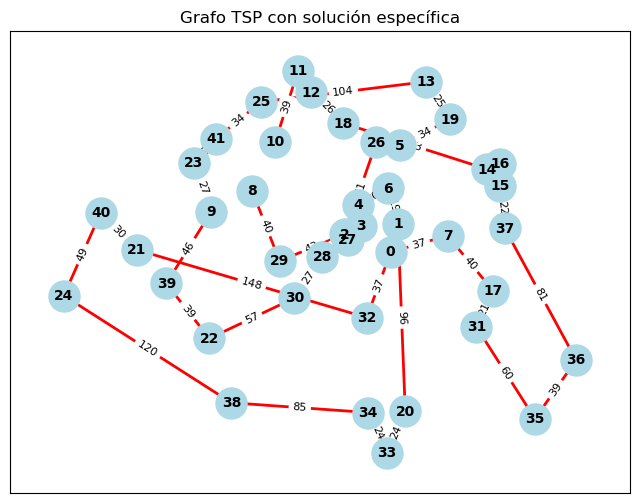

In [30]:
def algoritmo_genetico(problema=problem,tamano_poblacion=100,mutacion=0.15,elitismo=0.1,generaciones=100):
    # problema = datos del problema
    # tamano_poblacion = Tamaño de la población
    # mutacion = probabilidad de una mutación
    # elitismo = porcion de la mejor poblacion a mantener
    # generaciones = nº de generaciones a generar para finalizar

    # Genera la poblacion inicial
    nodos = list(problema.get_nodes())
    poblacion = generar_poblacion(nodos,tamano_poblacion)

    # Inicializamos valores para la mejor solucion
    mejor_solucion, mejor_distancia = evaluar_poblacion(poblacion, problema)

    # Inciamos el cliclo de generaciones
    for i in range (generaciones):
        # Cruce de la poblacion(incluye mutación)
        poblacion = cruzar(poblacion, mutacion, problema)

        #Seleccionamos la población
        poblacion = seleccionar(problema, poblacion, tamano_poblacion, elitismo)

        #Evaluamos la nueva población
        (mejor_solucion, mejor_distancia) = evaluar_poblacion(poblacion, problema)

        #print("Generacion #", i, "\nLa mejor solución es:" , mejor_solucion, "\ncon distancia " , mejor_distancia, "\n")

    return mejor_solucion, mejor_distancia

tamano_poblacion = 500
mutacion = 0.3
elitismo = 0.40
generaciones = 250

mejor_solucion, mejor_distancia = algoritmo_genetico(problem,tamano_poblacion,mutacion,elitismo,generaciones)

print(f"La mejor solución encontrada es: {mejor_solucion} con {generaciones} generaciones")
print(f"Distancia: {mejor_distancia}")

plot_tsp_solution(problem.edge_weights, mejor_solucion)